<a href="https://colab.research.google.com/github/priyalimbu246/assignments/blob/main/Priya_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 3 - Deadline 2/27/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Priya Limbu

**AI usage statement:**
I have used cloude and chatgpt mostly about how does things work and chatgpt for clarification of my codes. Tried to combine the codes and understanding the how things can be simple and clear. I tried to replicate your provided class notes/codes.

### Task 1 - 10 points

In this task, we will consider data from this paper:
- Enhancing Permeability Prediction of Heterobifunctional Degraders Using Machine Learning and Metadynamics-Informed 3D Molecular Descriptors - [DOI:10.1021/acs.jcim.5c01600](https://doi.org/10.1021/acs.jcim.5c01600)

Where the authors consider the Permeability of so-called PROTAC compounds that are large and flexible molecules used in Targeted Protein Degradation.

All the dataset used in the paper, and the code use to obtain the results are given in this following Github repository:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD  

The specfic dataset that we use 32 PROTAC compounds with measured passive permeability (given in nm/s) and includes 17 2D features calculated by RDKit (see [here](https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/data/calculate_2d_properties.py) for the script they are calculated), and 3 3D "ensemble" features that are obtained from molecular dynamics simulations as described in the paper.

The target value is the measured passive permeability that is experimentaly measured and given in nm/s.

The dataset can be seen here:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/outputs/ml_models/model_data.csv

Where the log10 transformed passive permeability is given by `P_appLog`. Note that here the passive permeability has been log transformed in based 10 using `np.log10`.

The 2D features obtained using RDKit are:
```
[
 'Molecular Weight (MW)', 'CharVol (characteristic volume)',
 'Flexibility (number of rotatable bonds / number of bonds)',
 'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
 'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
 'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
 'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
 'Topological polar surface area (TPSA)',
 'Total non-polar surface area (TNSA)'
]
```
that includes various standard descriptors/features implemented in RDKit

and the 3D "ensemble" features obtained using MD simulations are
```
[
 'Ensemble_Average_PSA_Chloroform_ANI',
 'Ensemble_Average_Num_IMHB_Chloroform_ANI',
 'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
```
which inludes the average polar surface area (PSA), the average number of intramolecular hydrogen bonds (IMHB), and the average radius of gyration (that measures if the molecule is compact or extended).

#### A)
Split the dataset into compounds with two classes with low and high permeability evenly so each class has 16 compounds.

#### B)
For all 32 compounds, visualize the 2D chemical structure using RDKit and the mols2grid package, and show their measured passive permeability in nm/s and their low/high permeability classifciation.

#### C)
Perform classifcation using random forest classification model using the following hyperparameters:
- Number of tree: 100
- Maximum depth of each tree: 2
- Maximum number of features for each tree: 50% of the number of input features (rounded up if that number is a fraction)

You should perform the classification using 3 different feature set:
- 2D RDKit features
- 3D Ensemble features
- Combined set of 2D and 3D features

For each case, perform cross validation (CV) using a CV strategy of your choice, and obtain the average and standard deviation of metrics that measure the performance, including:
- Accuracy
- Precision
- Receiver Operating Characteristic Area Under the Curve (ROC AUC)  

In your analysis and metrics, the high permeability class should be consider as the postive class.

Based on your analysis, which feature set gives the best results for the classifcation?

#### D) - Optional for 2 points
Repeat your analysis from C) using a $k$ nearest neighbors classifer (i.e., $k$ nearest neighbors vote). Use the default value of 5 neighbors.

Do you obtain the same results as in C)?



In [48]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/refs/heads/main/outputs/ml_models/"
dataset_filename="model_data.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

2d_features.csv
2d_features.csv.1
knn_cv_comparison.png
model_data.csv
model_data.csv.1
rf_cv_comparison.png
sample_data


In [49]:
%%bash
wget -q "https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/refs/heads/main/outputs/ml_models/model_data.csv"
wget -q "https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/refs/heads/main/data/2d_features.csv"
echo "Downloaded files:"
ls *.csv

Downloaded files:
2d_features.csv
model_data.csv


In [50]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, LeaveOneOut, RepeatedStratifiedKFold
from sklearn import metrics

In [51]:
df_main = pd.read_csv("model_data.csv")
df_2d   = pd.read_csv("2d_features.csv")



In [52]:
df_main["P_app_nms"] = df_2d["P_app"]
df_main["SMILES"]    = df_2d["Smiles"]



In [53]:
print(f"Dataset shape: {df_main.shape}")


Dataset shape: (32, 23)


In [54]:
df_main.head(10)

,Molecular Weight (MW),CharVol (characteristic volume),Flexibility (number of rotatable bonds / number of bonds),Number of Heavy Atoms (HA),RingAtoms,Halogens,HeteroAtoms,RotBonds (NRotB),AllBonds,RingCount,...,Hydrogen Bond Acceptors (HBA),cLogD^7.4,Topological polar surface area (TPSA),Total non-polar surface area (TNSA),Ensemble_Average_PSA_Chloroform_ANI,Ensemble_Average_Num_IMHB_Chloroform_ANI,Ensemble_Average_RadiusOfGyration_Chloroform_ANI,P_appLog,P_app_nms,SMILES
0,896.999,803.360,0.253521,65,42,0,19,18,71,7,...,14,2.64400,209.98,710.02,193.71,0.97,5.68,1.491362,31.016125,O=C(C(N1C(C2=CC=CC(NCCOCCOCCOCCC(N(CC3)CCN3C(C...
1,852.902,743.496,0.191176,62,42,0,19,13,68,7,...,13,1.76390,217.82,642.18,252.14,0.87,5.24,1.049218,11.171392,O=C(C(N1C(C2=CC=CC(NC(COCCOCC(N(CC3)CCN3C(C=C4...
2,850.930,753.592,0.191176,62,42,0,18,13,68,7,...,12,2.45750,208.59,671.41,248.01,0.67,5.47,0.812913,6.480741,O=C(C(N1C(C2=CC=CC(OCC(NCCCCC(N(CC3)CCN3C(C=C4...
3,1020.210,896.016,0.276316,71,33,3,20,21,76,6,...,12,7.70720,186.66,833.34,186.01,0.60,5.84,0.462398,2.900000,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...
4,1012.704,900.176,0.236842,70,39,1,20,18,76,7,...,14,7.42946,214.98,785.02,105.63,2.92,5.60,-0.397940,0.400000,CC1=NC(NC2=NC=C(C(=O)NC3=C(C)C=CC=C3Cl)S2)=CC(...
5,837.830,697.696,0.265625,59,34,3,19,17,64,6,...,12,4.40258,177.04,622.96,204.17,0.29,5.23,1.690196,49.000000,CC1(C)C(=O)N(C2=CC=C(C#N)C(C(F)(F)F)=C2)C(=S)N...
6,1006.183,872.816,0.266667,70,33,3,20,20,75,6,...,12,7.31710,186.66,813.34,175.16,0.32,5.41,1.136721,13.700000,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...
7,1128.150,931.232,0.256098,77,33,9,26,21,82,6,...,12,8.44280,186.66,833.34,160.07,0.93,5.93,0.505150,3.200000,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...
8,1022.182,891.056,0.276316,71,33,3,21,21,76,6,...,13,6.55350,195.89,804.11,197.66,1.64,5.16,1.235528,17.200000,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...
9,1078.143,902.096,0.253165,74,33,7,24,20,79,6,...,12,7.80750,186.66,813.34,217.11,0.00,5.63,0.113943,1.300000,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...


##A

In [55]:
# Using the median as the threshold to guarantee a balanced 16/16 split
threshold = df_main["P_app_nms"].median()
print(f"Permeability threshold (median): {threshold:.2f} nm/s")

df_main["perm_class"] = (df_main["P_app_nms"] > threshold).astype(int)
# label 1 = high permeability (positive class), 0 = low (negative class)

counts = df_main["perm_class"].value_counts().sort_index()
print(f"Low  permeability (class 0): {counts[0]} compounds")
print(f"High permeability (class 1): {counts[1]} compounds")

df_main[["P_app_nms", "perm_class"]].sort_values("P_app_nms")

Permeability threshold (median): 7.00 nm/s
Low  permeability (class 0): 16 compounds
High permeability (class 1): 16 compounds


,P_app_nms,perm_class
16,0.100000,0
15,0.300000,0
4,0.400000,0
14,1.000000,0
9,1.300000,0
3,2.900000,0
29,3.200000,0
7,3.200000,0
27,3.400000,0
25,3.800000,0


##B

In [56]:
%%capture
import sys
if "google.colab" in sys.modules:
    !pip install rdkit mols2grid -q

In [57]:
import mols2grid

# P_app for display
df_main["Permeability (nm/s)"] = df_main["P_app_nms"].round(1)
df_main["Class"] = df_main["perm_class"].map({1: "High", 0: "Low"})

mols2grid.display(
    df_main,
    smiles_col="SMILES",
    subset=["img", "Permeability (nm/s)", "Class"],
)

##Features

In [58]:
Features_2D = [
    'Molecular Weight (MW)',
    'CharVol (characteristic volume)',
    'Flexibility (number of rotatable bonds / number of bonds)',
    'Number of Heavy Atoms (HA)',
    'RingAtoms', 'Halogens', 'HeteroAtoms',
    'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
    'Fraction of sp3 Carbon Atoms (FSP3)',
    'Hydrogen Bond Donors (HBD)', 'Hydrogen Bond Acceptors (HBA)',
    'cLogD^7.4',
    'Topological polar surface area (TPSA)',
    'Total non-polar surface area (TNSA)',
]

Features_3D = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI',
]

Features_ALL = Features_2D + Features_3D

y = df_main["perm_class"].values

##C

In [59]:
def run_rf_cv(feature_names, y, label=""):
    """Fit a RandomForestClassifier with cross-validation and print metrics."""
    X = df_main[feature_names].values
    n_feats = len(feature_names)
    n_max   = math.ceil(n_feats * 0.5)

    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=2,
        max_features=n_max,
        random_state=7,        # different seed from reference
    )

    scoring_dict = {
        "accuracy" : "accuracy",
        "precision": metrics.make_scorer(metrics.precision_score,
                                         pos_label=1, zero_division=np.nan),
        "roc_auc"  : "roc_auc",
    }

    # Repeating Stratified 5-Fold(5 folds × 20 repeats = 100 evaluations)
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=7)
    cv_results = cross_validate(clf, X, y, scoring=scoring_dict, cv=rskf)

    print(f"\n{'='*50}")
    print(f" Random Forest — {label} ({n_feats} features, max_features={n_max})")
    print(f"{'='*50}")
    for metric_key, display_name in [("accuracy","Accuracy"),
                                     ("precision","Precision"),
                                     ("roc_auc","ROC AUC")]:
        vals = cv_results[f"test_{metric_key}"]
        print(f"  {display_name:<12}: {np.nanmean(vals):.3f} ± {np.nanstd(vals):.3f}")

    return cv_results

In [60]:
rf_2d  = run_rf_cv(Features_2D,  y, label="2D RDKit Features")
rf_3d  = run_rf_cv(Features_3D,  y, label="3D Ensemble Features")
rf_all = run_rf_cv(Features_ALL, y, label="Combined 2D + 3D Features")


 Random Forest — 2D RDKit Features (17 features, max_features=9)
  Accuracy    : 0.415 ± 0.168
  Precision   : 0.386 ± 0.256
  ROC AUC     : 0.382 ± 0.234

 Random Forest — 3D Ensemble Features (3 features, max_features=2)
  Accuracy    : 0.788 ± 0.136
  Precision   : 0.805 ± 0.170
  ROC AUC     : 0.867 ± 0.131

 Random Forest — Combined 2D + 3D Features (20 features, max_features=10)
  Accuracy    : 0.731 ± 0.153
  Precision   : 0.730 ± 0.199
  ROC AUC     : 0.753 ± 0.191


##Visualisation for comparision

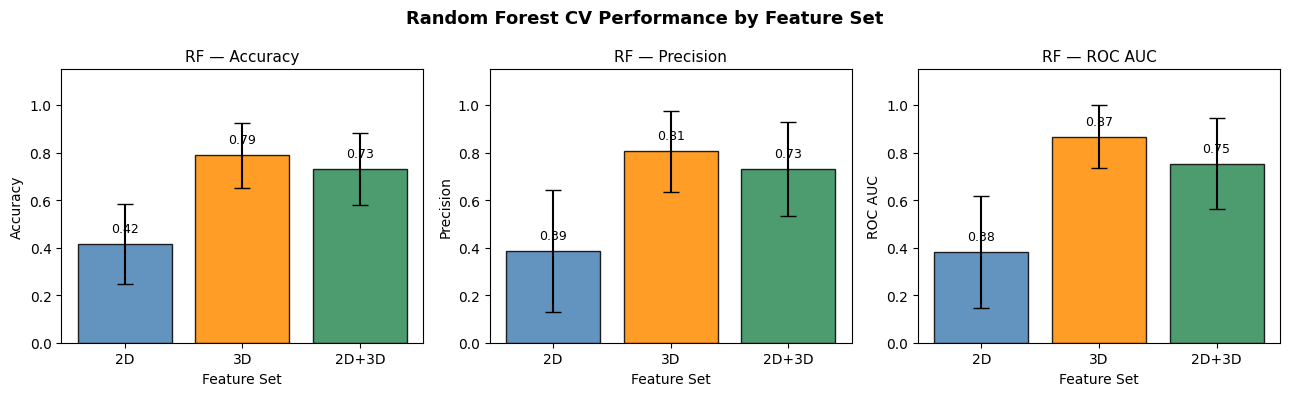

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

metric_keys  = ["test_accuracy", "test_precision", "test_roc_auc"]
metric_names = ["Accuracy", "Precision", "ROC AUC"]
result_sets  = [rf_2d, rf_3d, rf_all]
set_labels   = ["2D", "3D", "2D+3D"]
colors       = ["steelblue", "darkorange", "seagreen"]

for ax, key, name in zip(axes, metric_keys, metric_names):
    means = [np.nanmean(r[key]) for r in result_sets]
    stds  = [np.nanstd(r[key])  for r in result_sets]
    bars  = ax.bar(set_labels, means, yerr=stds, color=colors,
                   capsize=6, edgecolor="black", alpha=0.85)
    ax.set_title(f"RF — {name}", fontsize=11)
    ax.set_ylabel(name)
    ax.set_xlabel("Feature Set")
    ax.set_ylim(0, 1.15)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05,
                f"{mean:.2f}", ha="center", fontsize=9)

plt.suptitle("Random Forest CV Performance by Feature Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_cv_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## DISCUSSION:
The 3D ensembles has the best ROC AUC and accuracy, despite having only 3 features incomparision of 17 2D descriptors. Their conformational properties such as PSA, IMHB, radius of gyration etc are directly relevant to PROTAC membrane permeability.
Combining or adding 2D features to the 3D set slightly lowers the  performance with only 32 compounds, the extra features introduce noise, even with max_depth=2.

##D(OPT)

In [62]:
def run_knn_cv(feature_names, y, label="", k=5):
    """Fit a KNN pipeline (with StandardScaler) using cross-validation."""
    X = df_main[feature_names].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k)),
    ])

    scoring_dict = {
        "accuracy" : "accuracy",
        "precision": metrics.make_scorer(metrics.precision_score,
                                         pos_label=1, zero_division=np.nan),
        "roc_auc"  : "roc_auc",
    }

    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=7)
    cv_results = cross_validate(pipe, X, y, scoring=scoring_dict, cv=rskf)

    print(f"\n{'='*50}")
    print(f" KNN (k={k}) — {label} ({len(feature_names)} features)")
    print(f"{'='*50}")
    for metric_key, display_name in [("accuracy","Accuracy"),
                                     ("precision","Precision"),
                                     ("roc_auc","ROC AUC")]:
        vals = cv_results[f"test_{metric_key}"]
        print(f"  {display_name:<12}: {np.nanmean(vals):.3f} ± {np.nanstd(vals):.3f}")

    return cv_results

In [63]:
knn_2d  = run_knn_cv(Features_2D,  y, label="2D RDKit Features")
knn_3d  = run_knn_cv(Features_3D,  y, label="3D Ensemble Features")
knn_all = run_knn_cv(Features_ALL, y, label="Combined 2D + 3D Features")


 KNN (k=5) — 2D RDKit Features (17 features)
  Accuracy    : 0.484 ± 0.219
  Precision   : 0.475 ± 0.309
  ROC AUC     : 0.486 ± 0.257

 KNN (k=5) — 3D Ensemble Features (3 features)
  Accuracy    : 0.616 ± 0.166
  Precision   : 0.628 ± 0.195
  ROC AUC     : 0.677 ± 0.186

 KNN (k=5) — Combined 2D + 3D Features (20 features)
  Accuracy    : 0.486 ± 0.188
  Precision   : 0.488 ± 0.220
  ROC AUC     : 0.471 ± 0.225


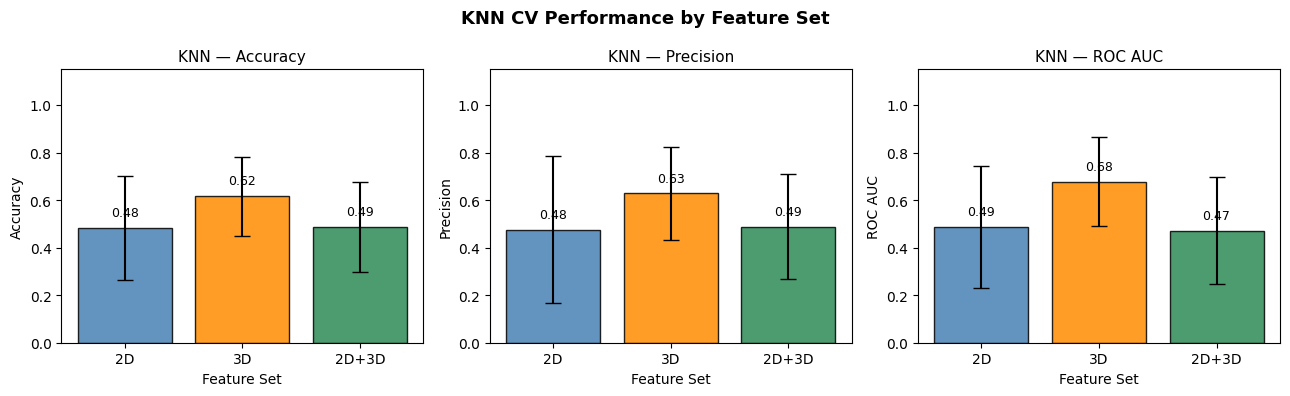

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, key, name in zip(axes, metric_keys, metric_names):
    means = [np.nanmean(r[key]) for r in [knn_2d, knn_3d, knn_all]]
    stds  = [np.nanstd(r[key])  for r in [knn_2d, knn_3d, knn_all]]
    bars  = ax.bar(set_labels, means, yerr=stds, color=colors,
                   capsize=6, edgecolor="black", alpha=0.85)
    ax.set_title(f"KNN — {name}", fontsize=11)
    ax.set_ylabel(name)
    ax.set_xlabel("Feature Set")
    ax.set_ylim(0, 1.15)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05,
                f"{mean:.2f}", ha="center", fontsize=9)

plt.suptitle("KNN CV Performance by Feature Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("knn_cv_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

##Discussion
KNN confirms the same ranking 3D > Combined > 2D but gives lower ROC AUC than than the Random Forest overall. KNN is sensitive to irrelevant features, so the 17 2D descriptors weakens the 3D features. Random Forest handles this better by implicitly selecting features at each split. **Conclusion, Both models agreed that 3D features are most informative, and Random Forest is the stronger choice for this small dataset**.